In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from utils.simulacoes import simular_fuzzy,simular_step_test

import skfuzzy as fuzz
from skfuzzy import control as ctrl


## analisando comportamento

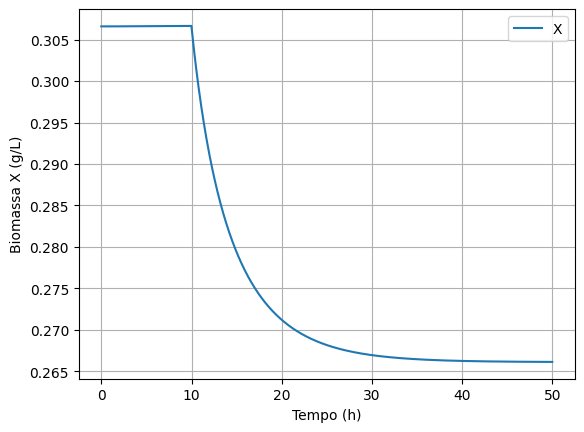

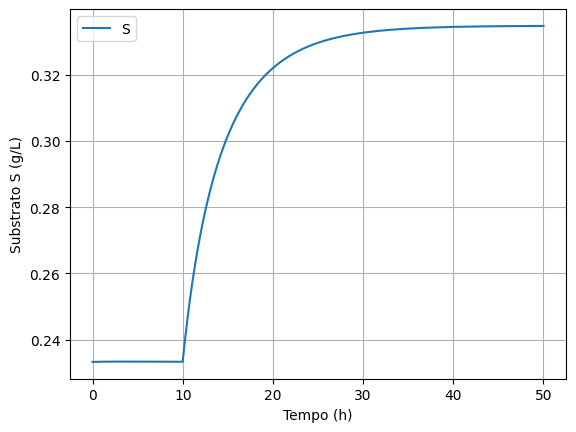

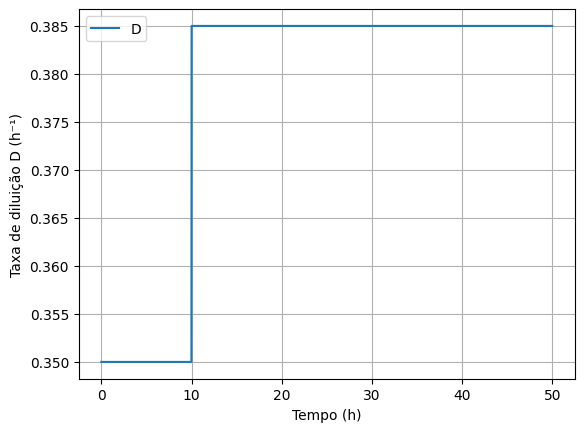

In [3]:
# entrada manipulada fixada em D0 - sem PID
# Aplicando  5% na saída do controlador em t = 10 h.
Xsp = 0.3066
step_time = 10
t, X, S, D = simular_step_test(D0=0.35, Xsp=Xsp, step_percent=0.1, step_time=step_time, states=np.array([0.3066, 0.2333]), tempo_final=50, dt=0.01)

In [4]:
e = Xsp - np.array(X)
print(f"x_max:{max(X)}, x_min:{min(X)}")
print(f"D_max:{max(D)}, D_min:{min(D)}")
print(f"e_max:{max(e)}, e_min:{min(e)}")
de = np.diff(e) / 0.01
de_min = np.min(de)
de_max = np.max(de)
print(f"de_max:{de_max}, de_min:{de_min}")

x_max:0.3066560011225969, x_min:0.2661117890287759
D_max:0.385, D_min:0.35
e_max:0.04048821097122407, e_min:-5.600112259690482e-05
de_max:0.010709768739769476, de_min:-8.65337421163126e-06


## descrição

rótulos linguísticos cada variável vai ter
erro:

* NG
* NP
* ZE
* PP
* PG

Variação do erro:

* NG
* NP
* ZE
* PP
* PG

Em que, 
* Negativo Grande (NG)
* Negativo Pequeno (NP)
* Zero (ZE)
* Positivo Pequeno (PP)
* Positivo Grande (PG)

Saída $\Delta D$:

* Reduzir Muito
* Reduzir Pouco
* Manter
* Aumentar Pouco
* Aumentar Muito

Os universos

| Variável   | Universo de discurso |
| ---------- | -------------------- |
| e          | $[-0.05,0.05]$      |
| $\Delta e$ | $[-0.02,0.02]$      |
| $\Delta D$ | $[-0.002,0.002]$      |


In [5]:
# Universos
e = ctrl.Antecedent(
    np.linspace(-0.05, 0.05, 1000),
    'erro'
)

de = ctrl.Antecedent(
    np.linspace(-0.02, 0.02, 1000),
    'delta_erro'
)

dD = ctrl.Consequent(
    np.linspace(-0.002, 0.002, 1000),
    'delta_D'
)


Com faixas

| Variável   | NG / Reduzir Muito | NP / Reduzir Pouco | ZE / Manter | PP / Aumentar Pouco | PG / Aumentar Muito |
| ---------- | -----------------: | -----------------: | ----------: | ------------------: | ------------------: |
| (e)        |              -0.05 |             -0.03 |        0.00 |               0.03 |                0.05 |
| (\Delta e) |              -0.02 |              -0.01 |        0.00 |                0.01 |                0.02 |
| (\Delta D) |              -0.002 |              -0.001 |        0.00 |                0.001 |                0.002 |

Funções de pertinência:

Para e:
| Rótulo | Triângulo             |
| ------ | --------------------- |
| NG     | (-0.05, -0.05, -0.01) |
| NP     | (-0.03, -0.01, 0)     |
| ZE     | (-0.001, 0, 0.001)    |
| PP     | (0, 0.01, 0.03)       |
| PG     | (0.01, 0.05, 0.05)    |

Para $\Delta e$:

| Rótulo | Função triangular        |
| ------ | ------------------------ |
| NG     | (-0.02, -0.02, -0.006) |
| NP     | (-0.012, -0.005, 0)    |
| ZE     | (-0.001, 0, 0.001)     |
| PP     | (0, 0.005, 0.012)      |
| PG     | (0.006, 0.02, 0.02)    |

Para $\Delta D$:

| Rótulo | Função triangular       |
| ------ | ----------------------- |
| RM     | (-0.002, -0.002, -0.001) |
| RP     | (-0.002, -0.001, 0)     |
| M      | (-0.0002, 0, 0.0002)      |
| AP     | (0, 0.001, 0.002)       |
| AM     | (0.001, 0.002, 0.002)    |

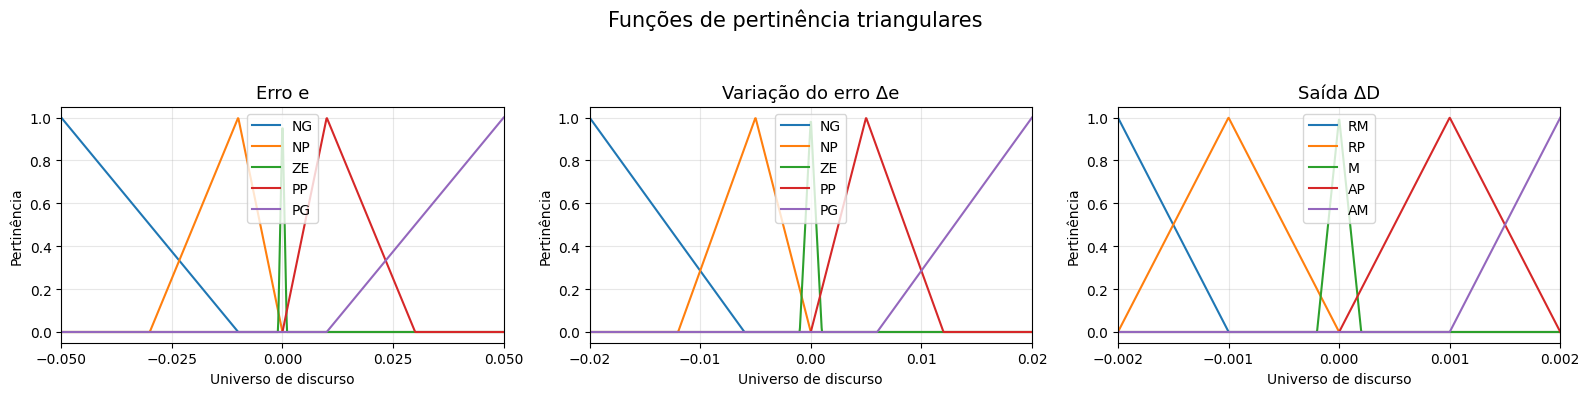

In [6]:
# erro
e['NG'] = fuzz.trimf(e.universe, [-0.05, -0.05, -0.01])
e['NP'] = fuzz.trimf(e.universe, [-0.03, -0.01,  0.00])
e['ZE'] = fuzz.trimf(e.universe, [-0.001, 0.00, 0.001])
e['PP'] = fuzz.trimf(e.universe, [ 0.00,  0.01, 0.03])
e['PG'] = fuzz.trimf(e.universe, [ 0.01,  0.05, 0.05])

# variação do e
de['NG'] = fuzz.trimf(de.universe, [-0.02, -0.02, -0.006])
de['NP'] = fuzz.trimf(de.universe, [-0.012, -0.005, 0.00])
de['ZE'] = fuzz.trimf(de.universe, [-0.001, 0.00, 0.001])
de['PP'] = fuzz.trimf(de.universe, [ 0.00, 0.005, 0.012])
de['PG'] = fuzz.trimf(de.universe, [ 0.006, 0.02, 0.02])

# saida variação D
dD['RM'] = fuzz.trimf(dD.universe, [-0.002, -0.002, -0.001])
dD['RP'] = fuzz.trimf(dD.universe, [-0.002, -0.001,  0.000])
dD['M']  = fuzz.trimf(dD.universe, [-0.0002, 0.000, 0.0002])
dD['AP'] = fuzz.trimf(dD.universe, [ 0.000,  0.001, 0.002])
dD['AM'] = fuzz.trimf(dD.universe, [ 0.001,  0.002, 0.002])

# e.view()
# de.view()
# dD.view()
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

variaveis = [e, de, dD]
titulos = ["Erro e", "Variação do erro Δe", "Saída ΔD"]

for ax, var, titulo in zip(axes, variaveis, titulos):

    for term in var.terms:
        ax.plot(var.universe, var[term].mf, label=term)

    ax.set_title(titulo, fontsize=13)
    ax.set_xlabel("Universo de discurso")
    ax.set_ylabel("Pertinência")
    ax.set_ylim(-0.05, 1.05)

    # deixa o eixo X bem distribuído
    xmin = np.min(var.universe)
    xmax = np.max(var.universe)
    ax.set_xlim(xmin, xmax)
    ax.set_xticks(np.linspace(xmin, xmax, 5))

    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle("Funções de pertinência triangulares", fontsize=15)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


Regras:

| e \ Δe | NG | NP | ZE | PP | PG |
| ------ | -- | -- | -- | -- | -- |
| NG     | AP |  AM | AM  | AM  | AP  |
| NP     | M  | AP  | AP  | AP  | AP  |
| ZE     | AP | AP  | M  | RP  | RP  |
| PP     | AP  | M  | RP  | RP  |  RP |
| PG     | RP  | RM  | RM  | RM  | RP |


e(k) - e(k-1) > 0 -> erro cresceu -> afasto Xsp

e(k) - e(k-1) < 0 -> erro reduziu -> aproximo Xsp 

* e sendo PP + delta_e sendo NG -> D ser AP: Ainda estou abaixo do setpoint, mas estou chegando rápido demais; então vou aumentar um pouco D para frear. Assim como em

* ($e \approx 0$) e ($\Delta e < 0$): X está subindo e vai passar do setpoint -> aumentar D para frear

* ($e \approx 0$) e ($\Delta e > 0$): X está caindo e vai ficar abaixo do setpoint -> reduzir D para frear a queda

* ($e \approx 0$) e ($\Delta e \approx 0$): manter D

* ($e > 0$) e ($\Delta e < 0$ pequeno): X tá abaixo do Xsp e vai passar do setpoint -> aumentar pouco D para frear ou mantenho

* ($e < 0$) e ($\Delta e < 0$ grande): X passou do Xsp e continua subindo -> aumentar muito D

só que isso talvez esteja aplicando muito amortecimento... revisar





In [7]:
regra1 = ctrl.Rule(e['NG'] & de['NG'], dD['AP'])
regra2 = ctrl.Rule(e['NG'] & de['NP'], dD['AM'])
regra3 = ctrl.Rule(e['NG'] & de['ZE'], dD['AM'])
regra4 = ctrl.Rule(e['NG'] & de['PP'], dD['AM'])
regra5 = ctrl.Rule(e['NG'] & de['PG'], dD['AP'])

regra6 = ctrl.Rule(e['NP'] & de['NG'], dD['M'])
regra7 = ctrl.Rule(e['NP'] & de['NP'], dD['AP'])
regra8 = ctrl.Rule(e['NP'] & de['ZE'], dD['AP'])
regra9 = ctrl.Rule(e['NP'] & de['PP'], dD['AP'])
regra10 = ctrl.Rule(e['NP'] & de['PG'], dD['AP'])

regra11 = ctrl.Rule(e['ZE'] & de['NG'], dD['AP'])
regra12 = ctrl.Rule(e['ZE'] & de['NP'], dD['AP'])
regra13 = ctrl.Rule(e['ZE'] & de['ZE'], dD['M'])
regra14 = ctrl.Rule(e['ZE'] & de['PP'], dD['RP'])
regra15 = ctrl.Rule(e['ZE'] & de['PG'], dD['RP'])

regra16 = ctrl.Rule(e['PP'] & de['NG'], dD['AP'])
regra17 = ctrl.Rule(e['PP'] & de['NP'], dD['M'])
regra18 = ctrl.Rule(e['PP'] & de['ZE'], dD['RP'])
regra19 = ctrl.Rule(e['PP'] & de['PP'], dD['RP'])
regra20 = ctrl.Rule(e['PP'] & de['PG'], dD['RP'])

regra21 = ctrl.Rule(e['PG'] & de['NG'], dD['RP'])
regra22 = ctrl.Rule(e['PG'] & de['NP'], dD['RM'])
regra23 = ctrl.Rule(e['PG'] & de['ZE'], dD['RM'])
regra24 = ctrl.Rule(e['PG'] & de['PP'], dD['RM'])
regra25 = ctrl.Rule(e['PG'] & de['PG'], dD['RP'])

regras = [
    regra1, regra2, regra3, regra4, regra5,
    regra6, regra7, regra8, regra9, regra10,
    regra11, regra12, regra13, regra14, regra15,
    regra16, regra17, regra18, regra19, regra20,
    regra21, regra22, regra23, regra24, regra25
]

In [8]:
## regras da primeira versão para comparar heheheh
regra1_v1 = ctrl.Rule(e['NG'] & de['NG'], dD['AP'])
regra2_v1 = ctrl.Rule(e['NG'] & de['NP'], dD['AM'])
regra3_v1 = ctrl.Rule(e['NG'] & de['ZE'], dD['AM'])
regra4_v1 = ctrl.Rule(e['NG'] & de['PP'], dD['AM'])
regra5_v1 = ctrl.Rule(e['NG'] & de['PG'], dD['AP'])

regra6_v1 = ctrl.Rule(e['NP'] & de['NG'], dD['M'])
regra7_v1 = ctrl.Rule(e['NP'] & de['NP'], dD['AP'])
regra8_v1 = ctrl.Rule(e['NP'] & de['ZE'], dD['AP'])
regra9_v1 = ctrl.Rule(e['NP'] & de['PP'], dD['AP'])
regra10_v1 = ctrl.Rule(e['NP'] & de['PG'], dD['AP'])

regra11_v1 = ctrl.Rule(e['ZE'] & de['NG'], dD['M'])
regra12_v1 = ctrl.Rule(e['ZE'] & de['NP'], dD['M'])
regra13_v1 = ctrl.Rule(e['ZE'] & de['ZE'], dD['M'])
regra14_v1 = ctrl.Rule(e['ZE'] & de['PP'], dD['M'])
regra15_v1 = ctrl.Rule(e['ZE'] & de['PG'], dD['M'])

regra16_v1 = ctrl.Rule(e['PP'] & de['NG'], dD['M'])
regra17_v1 = ctrl.Rule(e['PP'] & de['NP'], dD['RP'])
regra18_v1 = ctrl.Rule(e['PP'] & de['ZE'], dD['RP'])
regra19_v1 = ctrl.Rule(e['PP'] & de['PP'], dD['RP'])
regra20_v1 = ctrl.Rule(e['PP'] & de['PG'], dD['RP'])

regra21_v1 = ctrl.Rule(e['PG'] & de['NG'], dD['RP'])
regra22_v1 = ctrl.Rule(e['PG'] & de['NP'], dD['RM'])
regra23_v1 = ctrl.Rule(e['PG'] & de['ZE'], dD['RM'])
regra24_v1 = ctrl.Rule(e['PG'] & de['PP'], dD['RM'])
regra25_v1 = ctrl.Rule(e['PG'] & de['PG'], dD['RP'])

regras_v1 = [
    regra1_v1, regra2_v1, regra3_v1, regra4_v1, regra5_v1,
    regra6_v1, regra7_v1, regra8_v1, regra9_v1, regra10_v1,
    regra11_v1, regra12_v1, regra13_v1, regra14_v1, regra15_v1,
    regra16_v1, regra17_v1, regra18_v1, regra19_v1, regra20_v1,
    regra21_v1, regra22_v1, regra23_v1, regra24_v1, regra25_v1
]

## Simulação

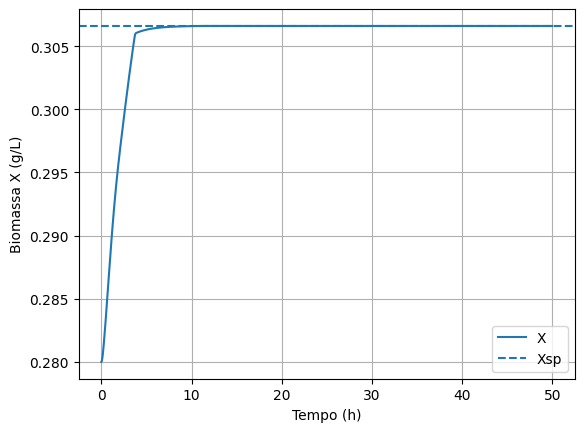

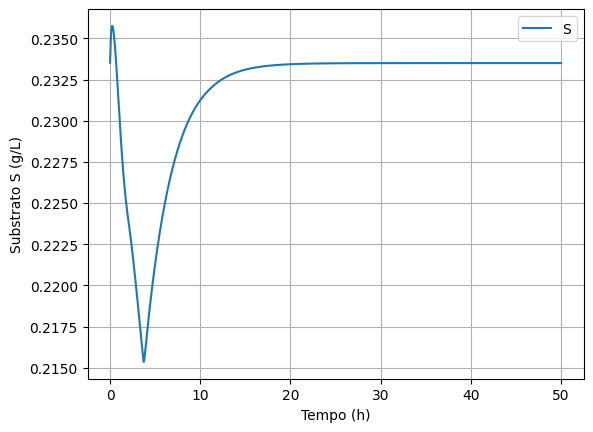

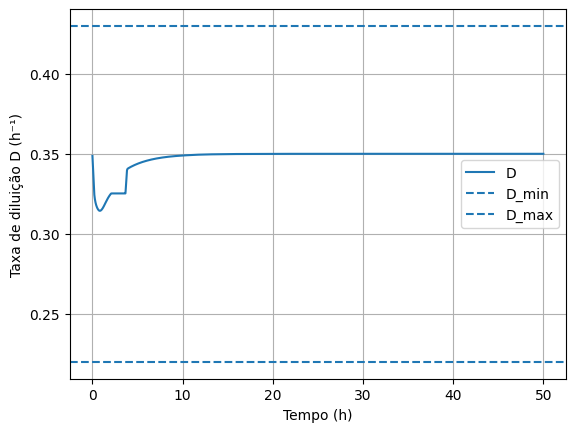

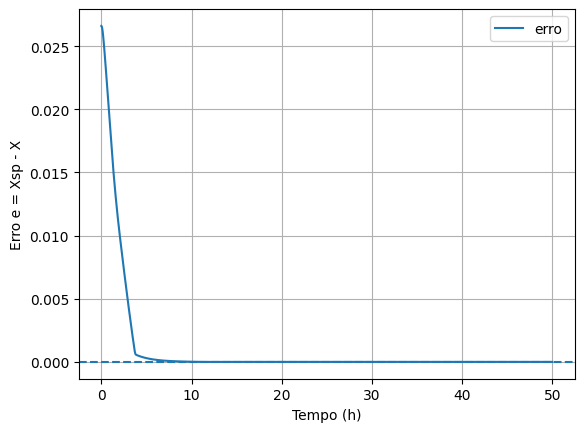

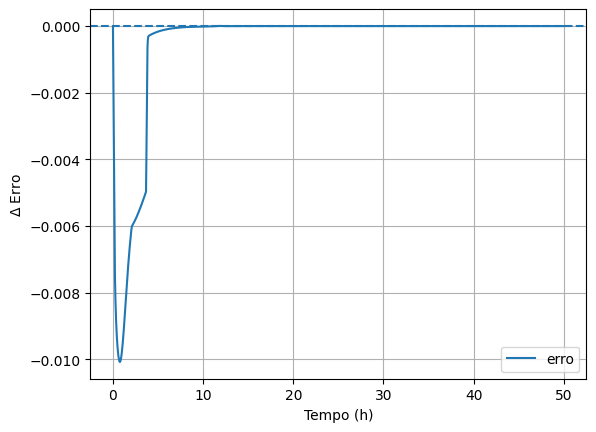

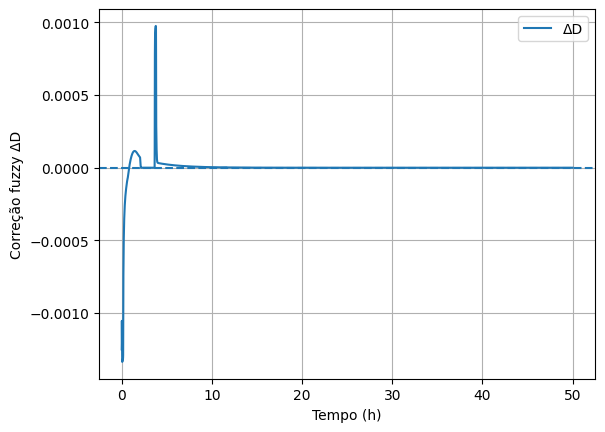

In [9]:
sistema = ctrl.ControlSystem(regras)

sim = ctrl.ControlSystemSimulation(sistema)

states=np.array([0.28, 0.2333])

tempo, X, S, D, sim_e, sim_de, sim_dD, metrics = simular_fuzzy(
    sim=sim,
    D0=0.35,
    states=states
)


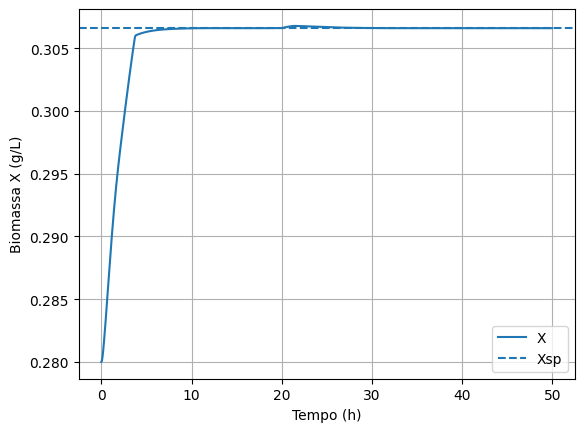

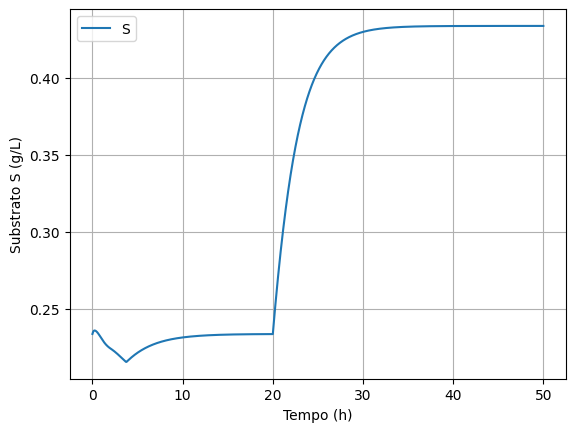

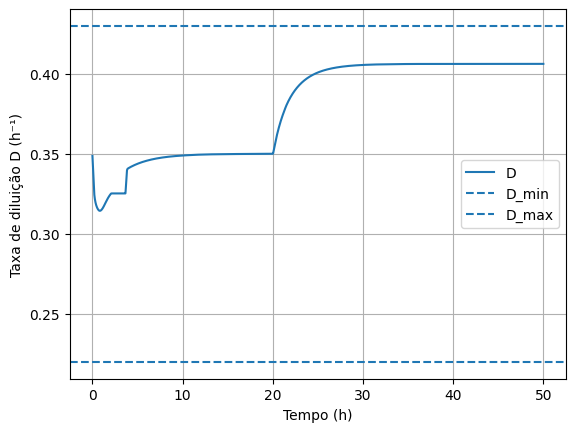

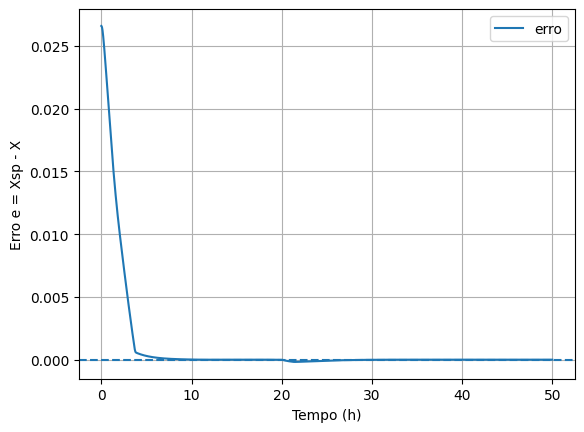

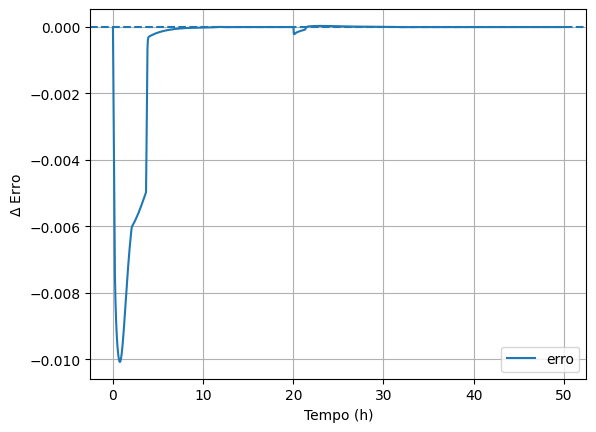

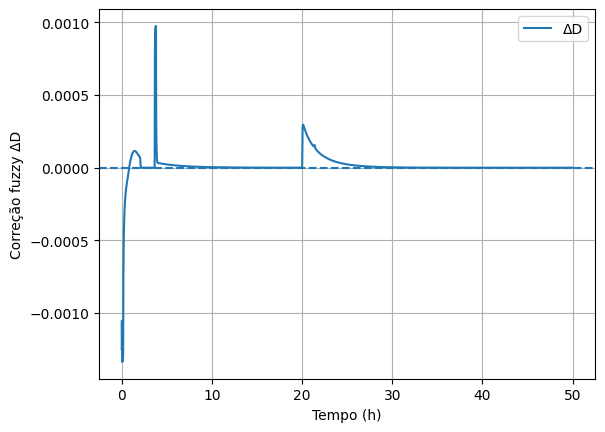

In [10]:
sistema = ctrl.ControlSystem(regras)

sim = ctrl.ControlSystemSimulation(sistema)

states=np.array([0.28, 0.2333])

tempo, X, S, D, sim_e, sim_de, sim_dD, metrics = simular_fuzzy(
    sim=sim,
    D0=0.35,
    states=states,
    pert=True,
    t_pert=20,
    Sf_pert=1.2
)

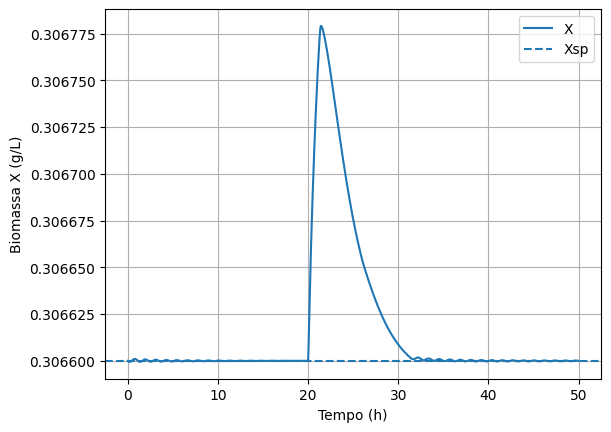

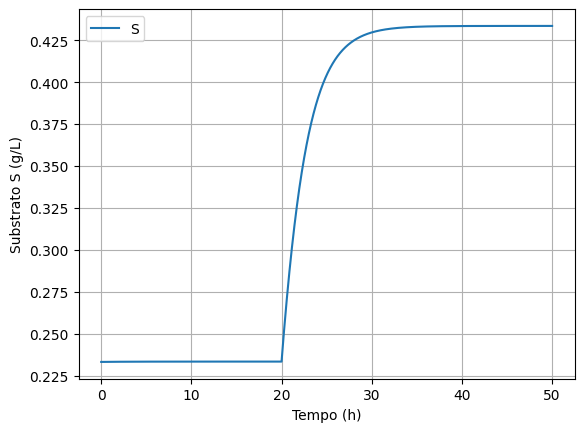

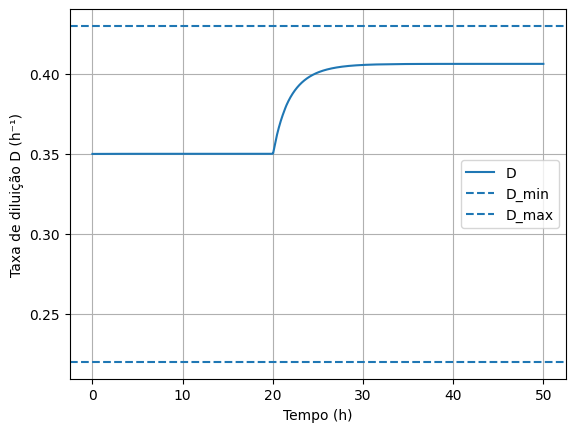

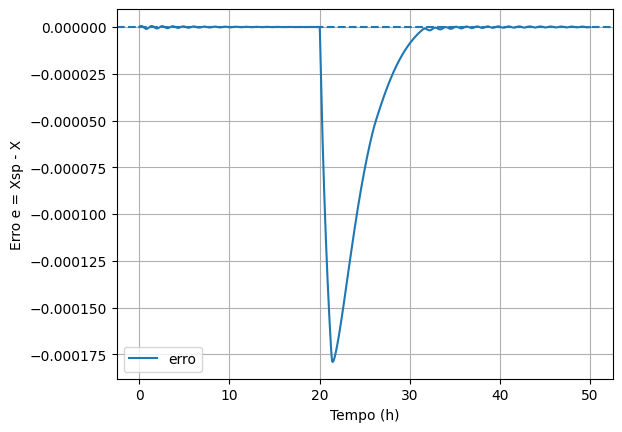

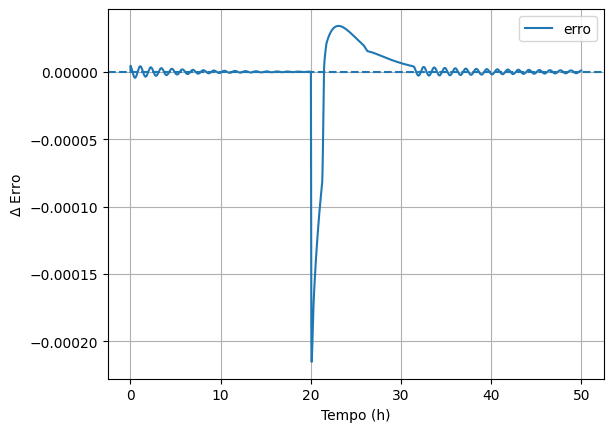

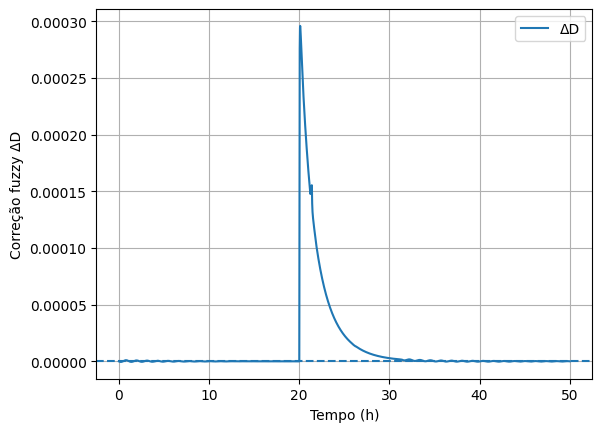

In [11]:
sistema = ctrl.ControlSystem(regras)

sim = ctrl.ControlSystemSimulation(sistema)

# states=np.array([0.28, 0.2333])

tempo, X, S, D, sim_e, sim_de, sim_dD, metrics = simular_fuzzy(
    sim=sim,
    D0=0.35,
    # states=states
    pert=True,
    t_pert=20,
    Sf_pert=1.2
)


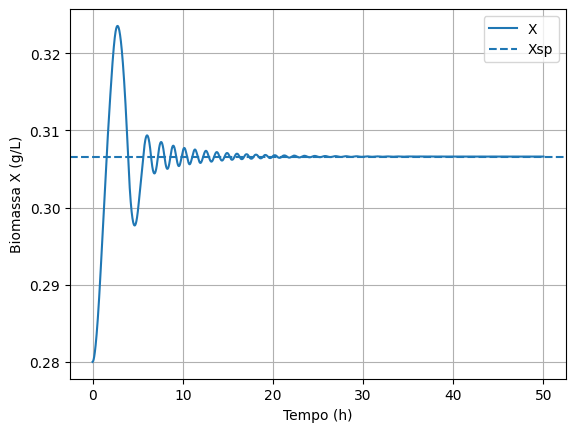

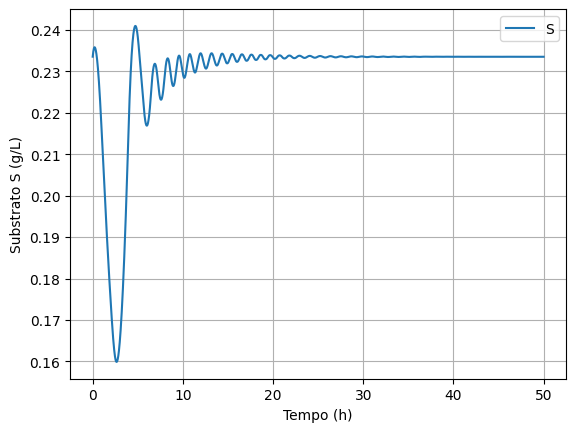

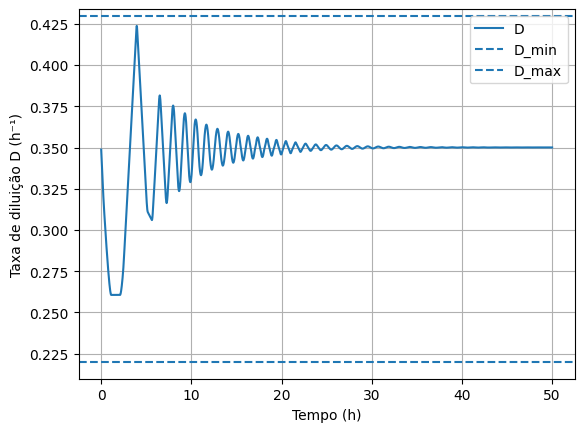

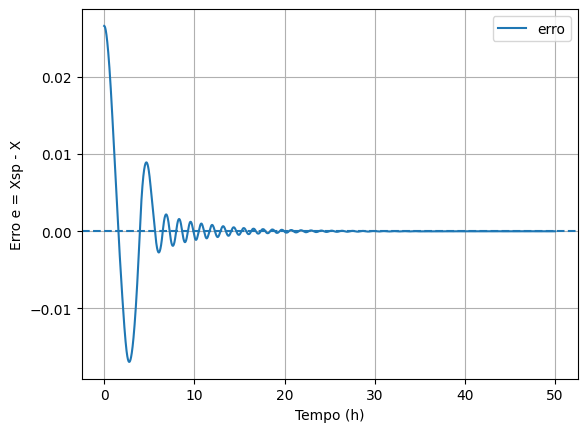

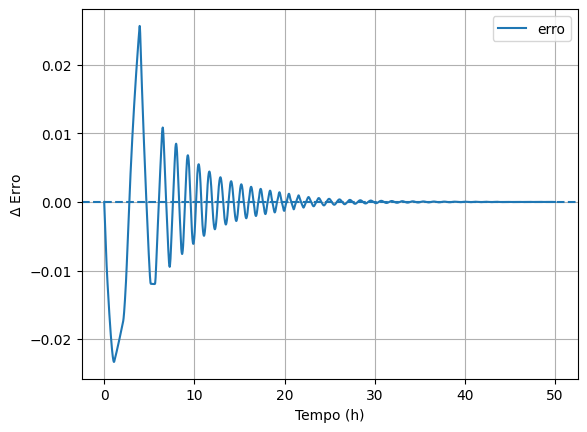

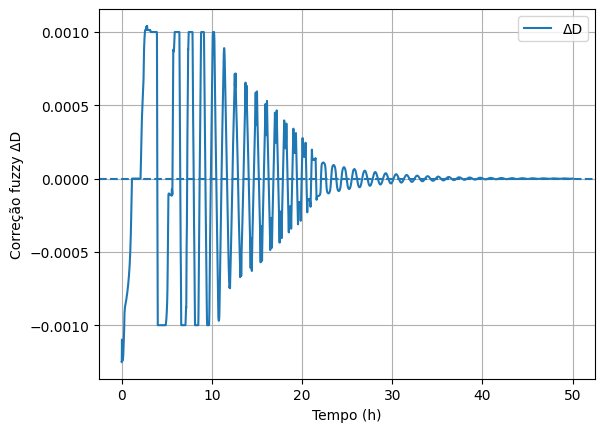

In [12]:
sistema = ctrl.ControlSystem(regras_v1)

sim = ctrl.ControlSystemSimulation(sistema)

states=np.array([0.28, 0.2333])

tempo, X_v1, S_v1, D_v1, sim_e_v1, sim_de_v1, sim_dD_v1, metrics_v1 = simular_fuzzy(
    sim=sim,
    D0=0.35,
    states=states
)


In [13]:
D = np.array(D)
dD = np.array(sim_dD)

TV_D = np.sum(np.abs(np.diff(D)))      # variação total de D
TV_dD = np.sum(np.abs(np.diff(dD)))    # suavidade da ação fuzzy

print(f"Overshoot = {metrics['overshoot']:.6f}")
print(f"Undershoot = {metrics['undershoot']:.6f}")
print(f"IAE = {metrics['IAE']:.6e}")
print(f"ISE = {metrics['ISE']:.6e}")
print(f"TV_D = {TV_D:.6f}")
print(f"TV_dD = {TV_dD:.6f}")

Overshoot = 0.000179
Undershoot = 0.000001
IAE = 8.092915e-04
ISE = 9.238069e-08
TV_D = 0.056725
TV_dD = 0.000644


In [14]:
D_v1 = np.array(D_v1)
dD_v1 = np.array(sim_dD_v1)

TV_D_v1 = np.sum(np.abs(np.diff(D_v1)))      # variação total de D
TV_dD_v1 = np.sum(np.abs(np.diff(dD_v1)))    # suavidade da ação fuzzy

print(f"Overshoot = {metrics_v1['overshoot']:.6f}")
print(f"Undershoot = {metrics_v1['undershoot']:.6f}")
print(f"IAE = {metrics_v1['IAE']:.6e}")
print(f"ISE = {metrics_v1['ISE']:.6e}")
print(f"TV_D = {TV_D_v1:.6f}")
print(f"TV_dD = {TV_dD_v1:.6f}")

Overshoot = 0.016923
Undershoot = 0.026596
IAE = 6.920984e-02
ISE = 9.169330e-04
TV_D = 1.129546
TV_dD = 0.048889


In [15]:
for i in range(len(tempo)):
    print(
    f"erro={sim_e[i]:.5f}",
    f"de={sim_de[i]:.5f}",
    f"dD={sim_dD[i]:.5f}",
    f"D={D[i]:.5f}"
)
    if i > 1000: break

erro=0.00000 de=0.00000 dD=0.00000 D=0.35000
erro=0.00000 de=0.00000 dD=-0.00000 D=0.35000
erro=0.00000 de=0.00000 dD=-0.00000 D=0.35000
erro=0.00000 de=0.00000 dD=-0.00000 D=0.35000
erro=0.00000 de=0.00000 dD=-0.00000 D=0.35000
erro=0.00000 de=0.00000 dD=-0.00000 D=0.35000
erro=0.00000 de=0.00000 dD=-0.00000 D=0.35000
erro=0.00000 de=0.00000 dD=-0.00000 D=0.35000
erro=0.00000 de=0.00000 dD=-0.00000 D=0.35000
erro=0.00000 de=0.00000 dD=-0.00000 D=0.35000
erro=0.00000 de=0.00000 dD=-0.00000 D=0.35000
erro=0.00000 de=0.00000 dD=-0.00000 D=0.35000
erro=0.00000 de=0.00000 dD=-0.00000 D=0.35000
erro=0.00000 de=0.00000 dD=-0.00000 D=0.35000
erro=0.00000 de=0.00000 dD=-0.00000 D=0.35000
erro=0.00000 de=0.00000 dD=-0.00000 D=0.35000
erro=0.00000 de=0.00000 dD=-0.00000 D=0.35000
erro=0.00000 de=0.00000 dD=-0.00000 D=0.34999
erro=0.00000 de=0.00000 dD=-0.00000 D=0.34999
erro=0.00000 de=0.00000 dD=-0.00000 D=0.34999
erro=0.00000 de=0.00000 dD=-0.00000 D=0.34999
erro=0.00000 de=0.00000 dD=-0.00000

In [16]:
print(np.min(sim_e))
print(np.max(sim_e))

-0.00017906561030306412
5.647687311149951e-07


In [17]:

def rodar_fuzzy(regras, **kwargs):
    sistema = ctrl.ControlSystem(regras)
    sim = ctrl.ControlSystemSimulation(sistema)

    tempo, X, S, D, sim_e, sim_de, sim_dD, metrics = simular_fuzzy(
        sim=sim,
        D0=0.35,
        **kwargs,
        show=False
    )

    return {
        "tempo": np.array(tempo),
        "X": np.array(X),
        "S": np.array(S),
        "D": np.array(D),
        "dD": np.array(sim_dD),
        "metrics": metrics
    }

def plotar_comparacao_fuzzy(
    atual,
    teste,
    titulo,
    Xsp=0.3066,
    t_pert=None,
    Sf_pert=None,
    labels=("versão atual", "versão de teste")
):
    tempo = atual["tempo"]

    fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)

    # fig.suptitle(titulo, fontsize=14)

    cor_atual = "crimson"
    cor_teste = "royalblue"

    # X
    axes[0].plot(
        tempo, teste["X"],
        label=labels[1],
        linewidth=1.6,
        color=cor_teste,
        alpha=0.75,
        zorder=2
    )

    axes[0].plot(
        tempo, atual["X"],
        label=labels[0],
        linewidth=2.4,
        color=cor_atual,
        zorder=3
    )

    axes[0].axhline(
        Xsp,
        linestyle="--",
        color="black",
        linewidth=1,
        label="Xsp",
        zorder=1
    )

    axes[0].set_ylabel("X (g/L)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # D
    axes[1].plot(
        tempo, teste["D"],
        label=labels[1],
        linewidth=1.6,
        color=cor_teste,
        alpha=0.75,
        zorder=2
    )

    axes[1].plot(
        tempo, atual["D"],
        label=labels[0],
        linewidth=2.4,
        color=cor_atual,
        zorder=3
    )

    axes[1].set_ylabel("D (h⁻¹)")
    axes[1].grid(True, alpha=0.3)

    # ΔD
    axes[2].plot(
        tempo, teste["dD"],
        label=labels[1],
        linewidth=1.5,
        color=cor_teste,
        alpha=0.70,
        zorder=2
    )

    axes[2].plot(
        tempo, atual["dD"],
        label=labels[0],
        linewidth=2.3,
        color=cor_atual,
        zorder=3
    )

    axes[2].axhline(
        0,
        linestyle="--",
        color="black",
        linewidth=1,
        zorder=1
    )

    axes[2].set_ylabel("ΔD")
    axes[2].set_xlabel("Tempo (h)")
    axes[2].grid(True, alpha=0.3)

    # Marca perturbação, quando existir
    if t_pert is not None:
        for ax in axes:
            ax.axvline(
                t_pert,
                linestyle=":",
                color="gray",
                linewidth=1.5,
                zorder=1
            )

        axes[0].text(
            t_pert,
            axes[0].get_ylim()[1],
            f" Sf → {Sf_pert}",
            va="top",
            ha="left",
            fontsize=10
        )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


def comparar_tres_cenarios(regras_atual, regras_teste):
    Xsp_default = 0.3066
    states_default = np.array([0.3066, 0.2333])
    states_diferente = np.array([0.28, 0.2333])

    cenarios = [
        {
            "titulo": "F1: estados default, Xsp default, perturbação Sf = 1.2 em t = 20 h",
            "kwargs": {
                "states": states_default,
                "Xsp": Xsp_default,
                "pert": True,
                "t_pert": 20,
                "Sf_pert": 1.2
            },
            "Xsp": Xsp_default,
            "t_pert": 20,
            "Sf_pert": 1.2
        },
        {
            "titulo": "F2: estados default, Xsp = 0.34, sem perturbação",
            "kwargs": {
                "states": states_default,
                "Xsp": 0.34,
                "pert": False
            },
            "Xsp": 0.34,
            "t_pert": None,
            "Sf_pert": None
        },
        {
            "titulo": "F3: estados diferentes do padrão, Xsp default, perturbação Sf = 1.2 em t = 20 h",
            "kwargs": {
                "states": states_diferente,
                "Xsp": Xsp_default,
                "pert": True,
                "t_pert": 20,
                "Sf_pert": 1.2
            },
            "Xsp": Xsp_default,
            "t_pert": 20,
            "Sf_pert": 1.2
        }
    ]

    resultados = []

    for cenario in cenarios:
        teste = rodar_fuzzy(regras_teste, **cenario["kwargs"])
        atual = rodar_fuzzy(regras_atual, **cenario["kwargs"])

        plotar_comparacao_fuzzy(
            atual=atual,
            teste=teste,
            titulo=cenario["titulo"],
            Xsp=cenario["Xsp"],
            t_pert=cenario["t_pert"],
            Sf_pert=cenario["Sf_pert"],
            labels=("versão atual", "versão inicial")
        )

        resultados.append({
            "titulo": cenario["titulo"],
            "atual": atual,
            "teste": teste
        })

    return resultados


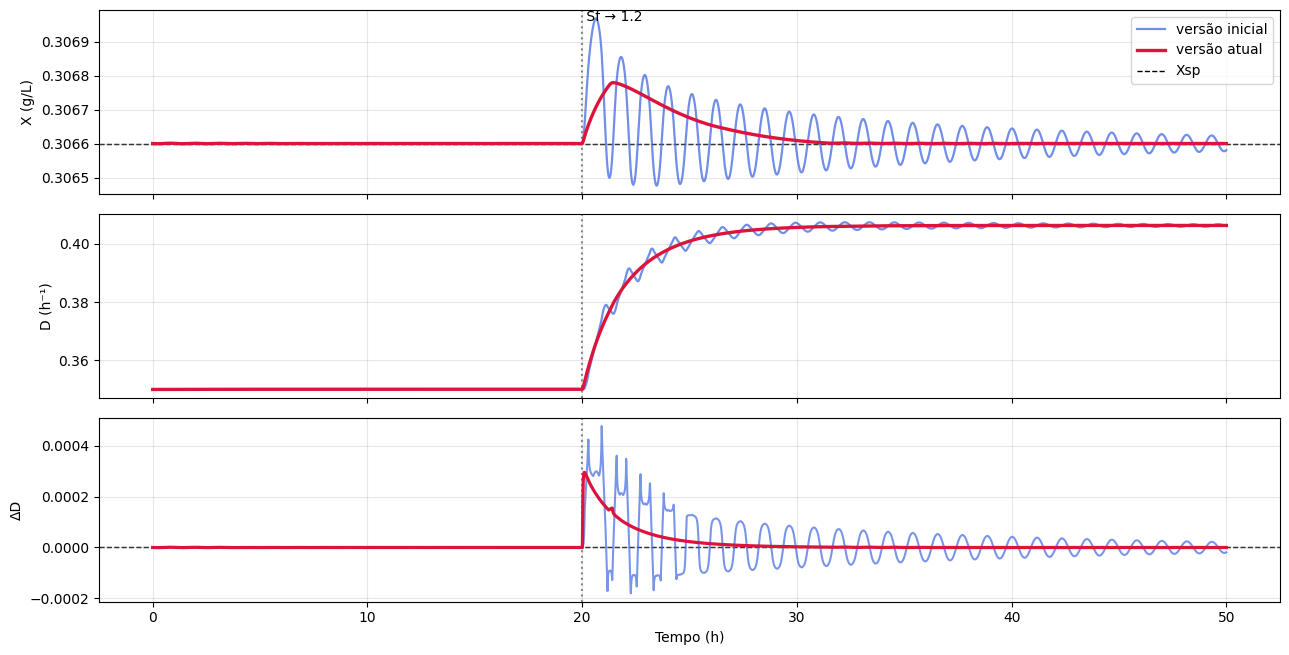

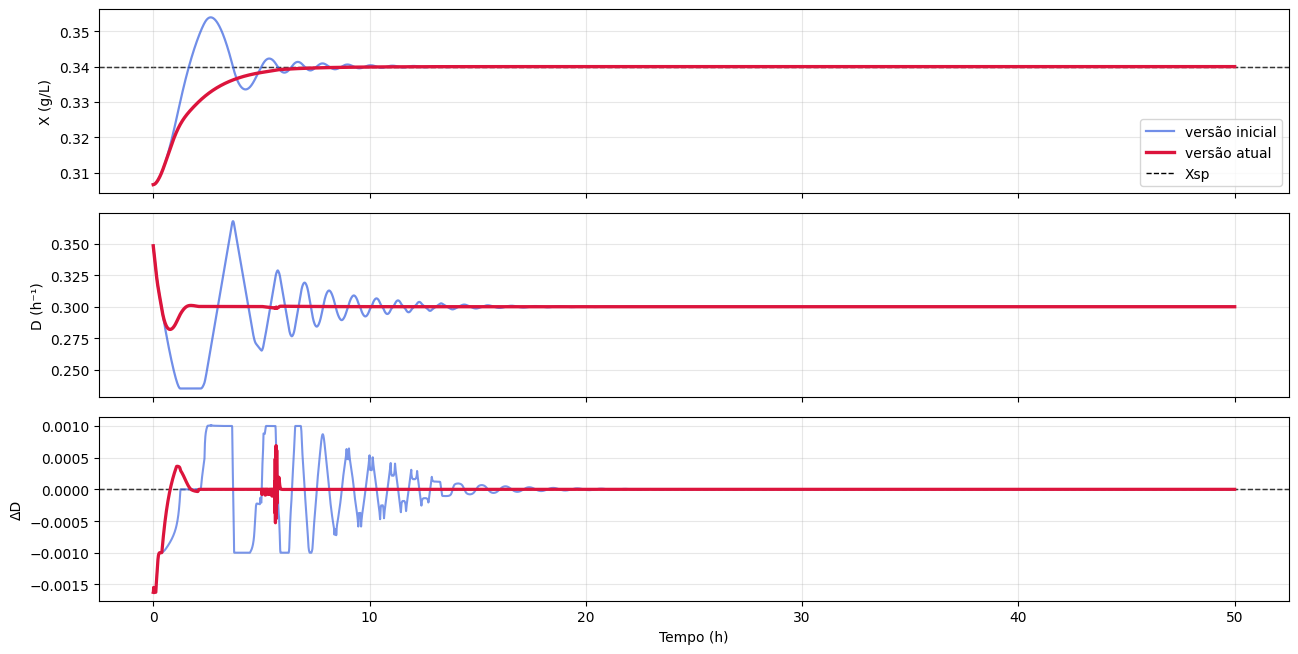

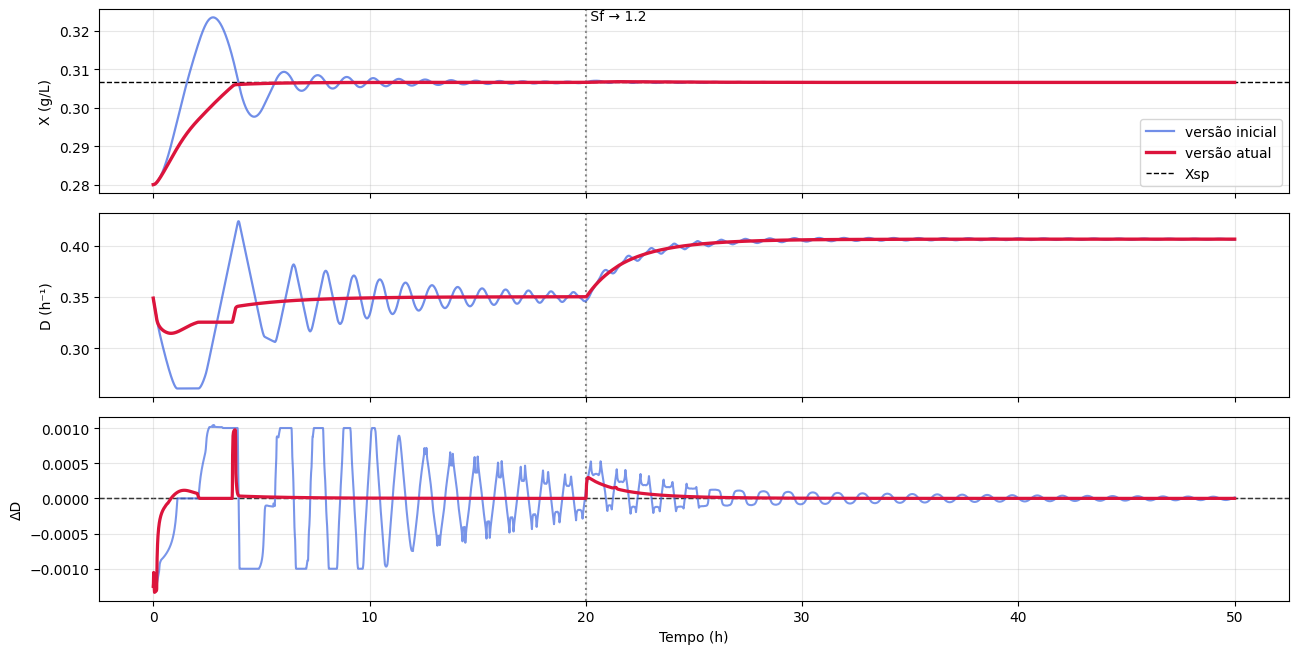

In [18]:
resultados = comparar_tres_cenarios(
    regras_atual=regras,
    regras_teste=regras_v1
)

In [22]:
resultados

[{'titulo': 'F1: estados default, Xsp default, perturbação Sf = 1.2 em t = 20 h',
  'atual': {'tempo': array([0.000e+00, 1.000e-02, 2.000e-02, ..., 4.998e+01, 4.999e+01,
          5.000e+01], shape=(5001,)),
   'X': array([0.30659995, 0.30659991, 0.30659987, ..., 0.30660002, 0.30660001,
          0.3066    ], shape=(5001,)),
   'S': array([0.23330081, 0.23330162, 0.23330242, ..., 0.4334988 , 0.43349883,
          0.43349886], shape=(5001,)),
   'D': array([0.35      , 0.34999996, 0.34999987, ..., 0.40628229, 0.40628231,
          0.40628231], shape=(5001,)),
   'dD': array([ 3.58067096e-20, -4.30313286e-08, -8.48795709e-08, ...,
           2.79725410e-08,  1.86439188e-08,  9.27613406e-09], shape=(5001,)),
   'metrics': {'IAE': np.float64(0.0008092914972641538),
    'ISE': np.float64(9.23806862804955e-08),
    'overshoot': np.float64(0.00017906561030306412),
    'undershoot': np.float64(5.647687311149951e-07)}},
  'teste': {'tempo': array([0.000e+00, 1.000e-02, 2.000e-02, ..., 4.998e+01